# DEG2MOL inference tutorial

This notebook previews an input DEG profile, calls the tested `inference.py` entry point, summarizes the generated molecules, and renders valid structures. Put the external data and checkpoints in the relative layout documented in `README.md` first.

In [1]:
from pathlib import Path
import subprocess
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if cwd.name == 'tutorial' else cwd

# ========================== USER SETTINGS ==========================
# Keep this as 'random' to use checkpoints/random/best_model.pt.
SPLIT = 'random'

# Change this to your DEG input file (.feather or .csv).
# Example: REPO_ROOT / 'data' / 'my_experiment' / 'custom_deg.csv'
INPUT_PATH = REPO_ROOT / 'data' / 'inference' / 'KO' / 'extra_test.feather'

# Change this if you want to save generated molecules elsewhere.
# Example: REPO_ROOT / 'outputs' / 'my_experiment'
OUTPUT_DIR = REPO_ROOT / 'outputs' / 'tutorial' / SPLIT

# Number of input DEG rows to process. Example: 10; use None for all rows.
NUM_INPUTS = 2

# Number of molecules generated for each DEG row. Example: 100.
NUM_MOLECULES_PER_INPUT = 10

# Classifier-free guidance strength. Example: 3.0.
GUIDANCE_SCALE = 3.0

# Flow integration steps. Example: 20 for a quick test or 100 for a full run.
NUM_STEPS = 100

# Maximum number of valid molecules shown in the structure grid. Example: 12.
MAX_MOLECULES_TO_DRAW = 12
# ======================== END USER SETTINGS ========================
print(f'Using the accepted {SPLIT}-split checkpoint.')

Using the accepted random-split checkpoint.


## 1. Preview the input DEG profiles

The table below shows the condition identifier and the first eight genes in the exact model input order.

In [2]:
import pandas as pd
from IPython.display import display

if not INPUT_PATH.is_file():
    raise FileNotFoundError(f'Input DEG table not found: {INPUT_PATH}')

if INPUT_PATH.suffix.lower() == '.feather':
    input_table = pd.read_feather(INPUT_PATH)
elif INPUT_PATH.suffix.lower() == '.csv':
    input_table = pd.read_csv(INPUT_PATH)
else:
    raise ValueError('INPUT_PATH must point to a .feather or .csv file.')

gene_order_path = REPO_ROOT / 'data' / 'BP' / 'gene_attribute_matrix_overlap_with_L1000.csv'
gene_names = pd.read_csv(gene_order_path, usecols=[0]).iloc[:, 0].dropna().astype(str).tolist()
missing_genes = [gene for gene in gene_names if gene not in input_table.columns]
if missing_genes:
    raise ValueError(f'The input table is missing {len(missing_genes)} required genes.')

preview_rows = NUM_INPUTS if NUM_INPUTS is not None else min(5, len(input_table))
preview_columns = ['cmap_name'] + gene_names[:8]
print(f'Input shape: {input_table.shape[0]:,} rows x {input_table.shape[1]:,} columns')
print(f'Required DEG features found: {len(gene_names):,}')
display(input_table.loc[:, preview_columns].head(preview_rows))

Input shape: 289 rows x 10,282 columns
Required DEG features found: 10,280


,cmap_name,A1CF,A2M,A4GALT,A4GNT,AAAS,AACS,AADAC,AAK1
XPR041_A549.311_96H:K01,AKT1,0.524786,0.232097,0.280503,0.451521,-1.220987,0.271250,-0.312971,0.510320
XPR041_DANG.311_96H:K01,AKT1,1.531954,0.111522,1.071788,0.540806,-0.972370,0.837968,1.268156,-0.327302


Text(0, 0.5, 'Gene')

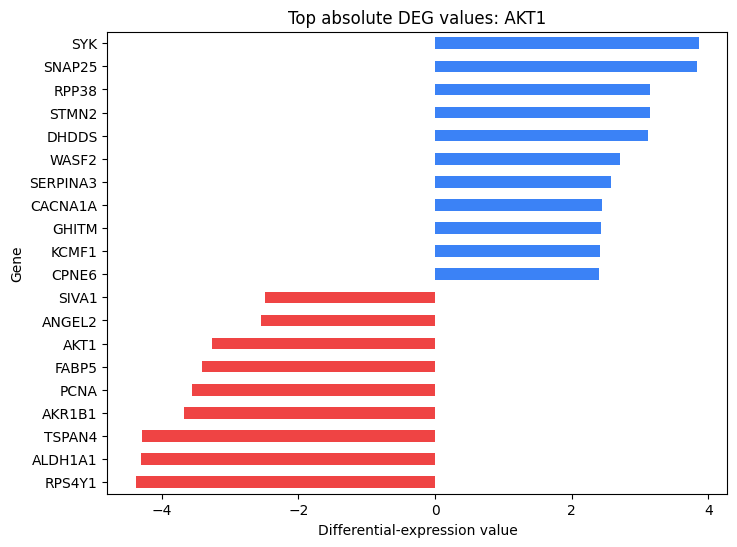

In [3]:
# Visualize the genes with the largest absolute values for the first DEG profile.
first_profile = input_table.loc[input_table.index[0], gene_names].astype(float)
top_gene_names = first_profile.abs().nlargest(20).index
ax = first_profile.loc[top_gene_names].sort_values().plot.barh(
    figsize=(8, 6),
    color=['#3b82f6' if value >= 0 else '#ef4444' for value in first_profile.loc[top_gene_names].sort_values()],
    title=f'Top absolute DEG values: {input_table.iloc[0]["cmap_name"]}',
)
ax.set_xlabel('Differential-expression value')
ax.set_ylabel('Gene')

## 2. Generate molecules

This cell uses the accepted random-split checkpoint through the repository's command-line inference implementation.

In [4]:
command = [
    sys.executable, str(REPO_ROOT / 'inference.py'),
    '--split', SPLIT,
    '--input-path', str(INPUT_PATH),
    '--output-dir', str(OUTPUT_DIR),
    '--num-samples', str(NUM_MOLECULES_PER_INPUT),
    '--num-steps', str(NUM_STEPS),
    '--guidance-scale', str(GUIDANCE_SCALE),
]
if NUM_INPUTS is not None:
    command.extend(['--max-samples', str(NUM_INPUTS)])

completed = subprocess.run(
    command, cwd=REPO_ROOT, check=True, capture_output=True, text=True
)
print(completed.stdout.replace(str(REPO_ROOT), '.').strip())

Generated 20 molecules for 2 DEG rows; 20 were RDKit-valid. Results: ./outputs/tutorial/random


## 3. Inspect the generated results

The summary reports the valid and unique molecules generated for each input profile. The detailed table preserves every generation attempt.

In [5]:
results_path = OUTPUT_DIR / 'generated_molecules.csv'
generated = pd.read_csv(results_path)
generated['valid'] = generated['valid'].astype(bool)
valid_generated = generated.loc[generated['valid'] & generated['smiles'].notna()].copy()

summary = generated.groupby(['input_index', 'cmap_name'], as_index=False).agg(
    generated_molecules=('sample_index', 'size'),
    valid_molecules=('valid', 'sum'),
)
unique_counts = (
    valid_generated.groupby(['input_index', 'cmap_name'])['smiles']
    .nunique()
    .rename('unique_valid_molecules')
    .reset_index()
)
summary = summary.merge(unique_counts, on=['input_index', 'cmap_name'], how='left')
summary['unique_valid_molecules'] = summary['unique_valid_molecules'].fillna(0).astype(int)
summary['validity'] = summary['valid_molecules'] / summary['generated_molecules']

display(summary)
display(generated.head(20))

,input_index,cmap_name,generated_molecules,valid_molecules,unique_valid_molecules,validity
0,0,AKT1,10,10,10,1.0
1,1,AKT1,10,10,10,1.0


,input_index,cmap_name,sample_index,smiles,valid
0,0,AKT1,0,CCCCN(C)c1ccc(NC(C)=O)cc1,True
1,0,AKT1,1,Cc1cnc2c(-c3ccc(C4CCCC4)o3)cnc(N(C)C)c2c1,True
2,0,AKT1,2,CC1CCN(C(C)CNC(=O)C=CNC2CCCCC2)CC1,True
3,0,AKT1,3,CNC(=O)CC=CC(=O)N(C)C(C)CC(C1c2ccccc2-c2ccccc2...,True
4,0,AKT1,4,CNCC(O)(NC(C)=O)c1cccc(Oc2ccccc2)c1,True
5,0,AKT1,5,CC(=O)CC(CNC1CCCCC1)NC(=O)c1cccc(O)c1,True
6,0,AKT1,6,CCN(C(=O)C1CCC(=O)N1)C(C)C1CCC(O)CC1,True
7,0,AKT1,7,CCCC(c1ccccn1)N1CC2CCC1(CC)CC2,True
8,0,AKT1,8,COc1cccc(COc2ccc(OC)c3c2CC2CCC(CN4C(=O)CCC4=O)...,True
9,0,AKT1,9,Cc1cccc(CCCONc2ccc(C)c3cnccc23)c1,True


## 4. Visualize valid generated molecules

Duplicate SMILES are removed before drawing. The same grid is saved as `generated_molecules_grid.png` in the output directory.

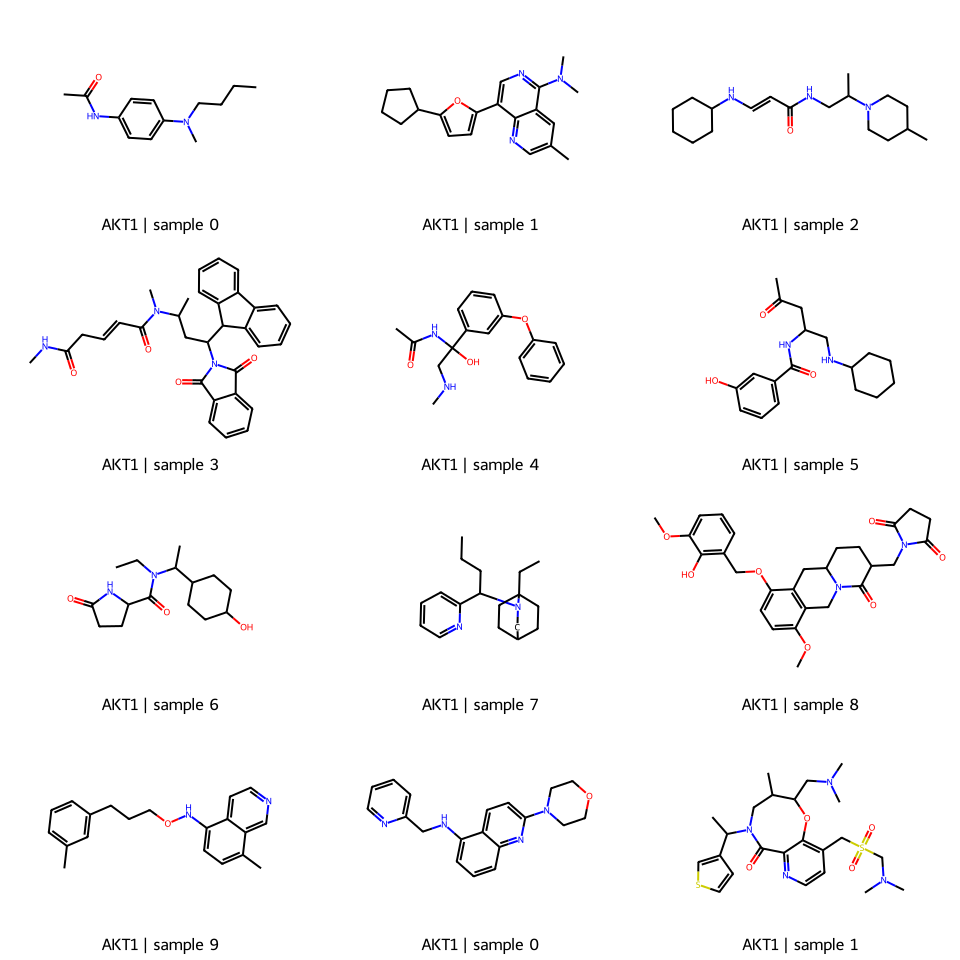

,cmap_name,sample_index,smiles
0,AKT1,0,CCCCN(C)c1ccc(NC(C)=O)cc1
1,AKT1,1,Cc1cnc2c(-c3ccc(C4CCCC4)o3)cnc(N(C)C)c2c1
2,AKT1,2,CC1CCN(C(C)CNC(=O)C=CNC2CCCCC2)CC1
3,AKT1,3,CNC(=O)CC=CC(=O)N(C)C(C)CC(C1c2ccccc2-c2ccccc2...
4,AKT1,4,CNCC(O)(NC(C)=O)c1cccc(Oc2ccccc2)c1
5,AKT1,5,CC(=O)CC(CNC1CCCCC1)NC(=O)c1cccc(O)c1
6,AKT1,6,CCN(C(=O)C1CCC(=O)N1)C(C)C1CCC(O)CC1
7,AKT1,7,CCCC(c1ccccn1)N1CC2CCC1(CC)CC2
8,AKT1,8,COc1cccc(COc2ccc(OC)c3c2CC2CCC(CN4C(=O)CCC4=O)...
9,AKT1,9,Cc1cccc(CCCONc2ccc(C)c3cnccc23)c1


Saved molecule grid: outputs/tutorial/random/generated_molecules_grid.png


In [6]:
import base64
from IPython.display import Image
from rdkit import Chem
from rdkit.Chem import Draw

molecule_rows = valid_generated.drop_duplicates('smiles').head(MAX_MOLECULES_TO_DRAW).copy()
molecules = []
legends = []
kept_rows = []
for row in molecule_rows.itertuples(index=False):
    molecule = Chem.MolFromSmiles(row.smiles)
    if molecule is not None:
        molecules.append(molecule)
        legends.append(f'{row.cmap_name} | sample {row.sample_index}')
        kept_rows.append(row)

if molecules:
    grid_output = Draw.MolsToGridImage(
        molecules, molsPerRow=3, subImgSize=(320, 240), legends=legends, returnPNG=True
    )
    grid_png = grid_output.data if hasattr(grid_output, 'data') else grid_output
    if isinstance(grid_png, str):
        grid_png = base64.b64decode(grid_png)
    grid_path = OUTPUT_DIR / 'generated_molecules_grid.png'
    grid_path.write_bytes(grid_png)
    display(Image(data=grid_png))
    display(pd.DataFrame(kept_rows).loc[:, ['cmap_name', 'sample_index', 'smiles']])
    print(f'Saved molecule grid: {grid_path.relative_to(REPO_ROOT)}')
else:
    print('No valid molecules were available to draw.')